# How-To: Scan Area Detector with Motor(s)

**Goals**

- Use an EPICS motor (`gp:m1`) as the independent axis.
- Use an EPICS area detector (`ad:`) to collect images at each step.
- Record ROI statistics (total counts, maximum value, unique ID) **without** saving image files.
- Run several scan plans: `bp.count`, `bp.scan` (1-D), `bp.scan` (2 motors), `bp.grid_scan` (2-D mesh).

This notebook requires a live EPICS system.  Use `ad:` for the area detector IOC and `gp:` for the general-purpose IOC (motors).

## Setup

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import databroker
import bluesky
import bluesky.plans as bp
from bluesky.callbacks.best_effort import BestEffortCallback
from ophyd import EpicsMotor

from apstools.devices import ad_creator
from apstools.devices import ensure_AD_plugin_primed

cat = databroker.temp()
RE = bluesky.RunEngine({})
RE.subscribe(cat.v1.insert)
bec = BestEffortCallback()
RE.subscribe(bec)

1

## EPICS Devices

Connect to the motor and the area detector.

In [2]:
m1 = EpicsMotor("gp:m1", name="m1")
m2 = EpicsMotor("gp:m2", name="m2")
m1.wait_for_connection(timeout=10)
m2.wait_for_connection(timeout=10)
print(f"{m1.connected=}  position={m1.position:.4f}")
print(f"{m2.connected=}  position={m2.position:.4f}")

m1.connected=True  position=1.0000
m2.connected=True  position=0.5000


Create the area detector using `ad_creator()`.  We include the `cam`, `image`, `pva`,
`roi1`, and `stats1` plugins.  The `hdf1` plugin is intentionally **omitted** here —
we want ROI statistics only, with no image files written.

In [3]:
IOC = "ad:"

adsimdet = ad_creator(
    IOC,
    name="adsimdet",
    plugins=["cam", "image", "pva", "roi1", "stats1"],
)
adsimdet.wait_for_connection(timeout=15)
print(f"{adsimdet.connected=}")

adsimdet.connected=True


## Configure the detector

Route the image through the ROI plugin into the Stats plugin, and select which
statistics signals to record.

In [4]:
# Wire up: cam -> roi1 -> stats1
adsimdet.roi1.nd_array_port.put(adsimdet.cam.port_name.get())
adsimdet.stats1.nd_array_port.put(adsimdet.roi1.port_name.get())

# One frame per trigger.
adsimdet.cam.stage_sigs["num_images"] = 1
adsimdet.cam.stage_sigs["wait_for_plugins"] = "Yes"

# Non-blocking callbacks for all plugins.
adsimdet.image.stage_sigs["blocking_callbacks"] = "No"
adsimdet.pva.stage_sigs["blocking_callbacks"] = "No"
adsimdet.roi1.stage_sigs["blocking_callbacks"] = "No"
adsimdet.stats1.stage_sigs["blocking_callbacks"] = "No"

# Hint the statistics signals we want in the scan table.
adsimdet.stats1.kind = "hinted"
adsimdet.stats1.total.kind = "hinted"
adsimdet.stats1.max_value.kind = "hinted"
adsimdet.stats1.unique_id.kind = "hinted"

## Visualise the plugin chain

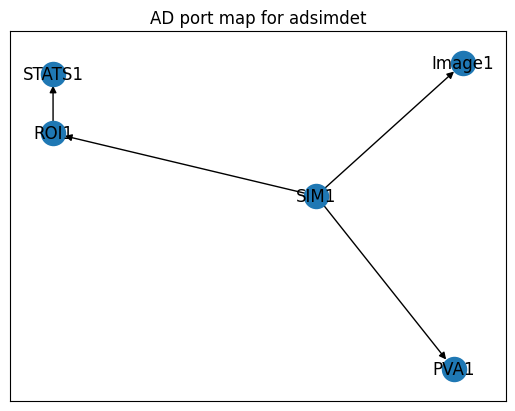

In [5]:
adsimdet.visualize_asyn_digraph()

## `bp.count` — collect statistics without a motor scan



Transient Scan ID: 1     Time: 2026-03-27 11:41:28
Persistent Unique Scan ID: 'bfde9351-44ae-44a4-93b0-6292493e146e'
New stream: 'primary'
+-----------+------------+---------------------------+---------------------------+-----------------------+
|   seq_num |       time | adsimdet_stats1_unique_id | adsimdet_stats1_max_value | adsimdet_stats1_total |
+-----------+------------+---------------------------+---------------------------+-----------------------+
|         1 | 11:41:28.3 |                      2226 |                       267 |              45806341 |


|         2 | 11:41:28.7 |                      2227 |                       266 |              45690804 |


|         3 | 11:41:29.1 |                      2228 |                       266 |              42281198 |


+-----------+------------+---------------------------+---------------------------+-----------------------+
generator count ['bfde9351'] (scan num: 1)


<xarray.Dataset> Size: 96B
Dimensions:                    (time: 3)
Coordinates:
  * time                       (time) float64 24B 1.775e+09 1.775e+09 1.775e+09
Data variables:
    adsimdet_stats1_total      (time) float64 24B 4.581e+07 4.569e+07 4.228e+07
    adsimdet_stats1_max_value  (time) float64 24B 266.6 265.6 266.5
    adsimdet_stats1_unique_id  (time) int64 24B 2226 2227 2228

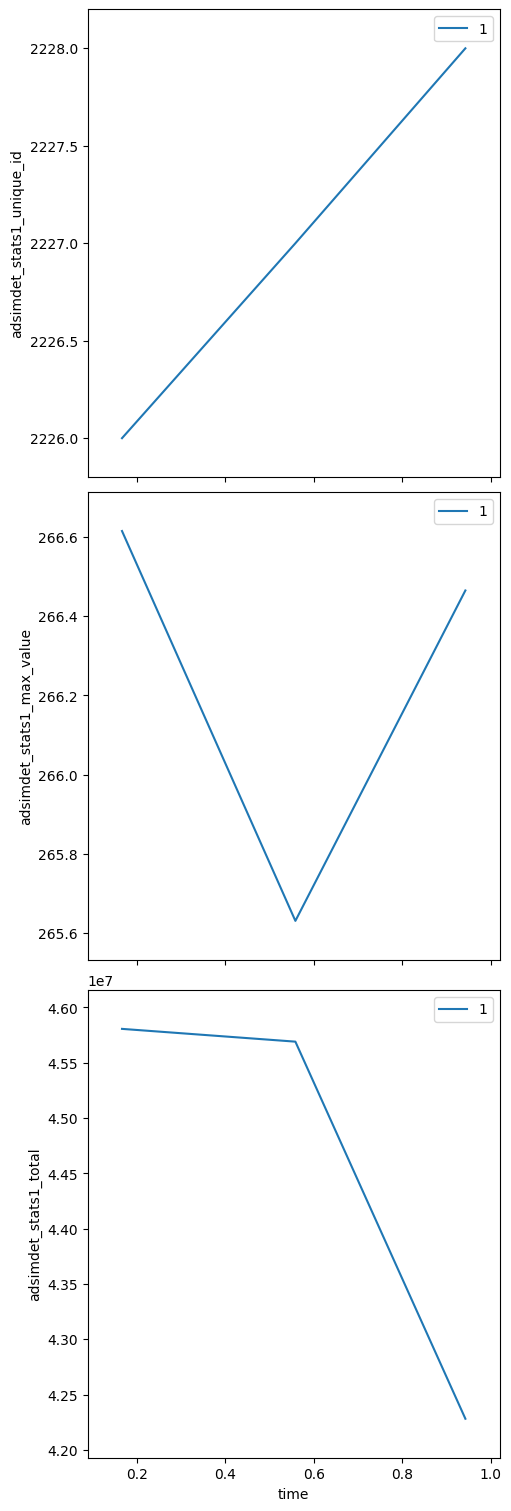

In [6]:
uids = RE(bp.count([adsimdet], num=3))
cat.v2[uids[-1]].primary.read()[["adsimdet_stats1_total", "adsimdet_stats1_max_value", "adsimdet_stats1_unique_id"]]

## `bp.scan` — 1-D scan with one motor

Step `m1` from −1 to +1 in 5 steps, collecting stats at each point.



Transient Scan ID: 2     Time: 2026-03-27 11:41:30
Persistent Unique Scan ID: '3ade749d-672d-49b6-b826-f598d92a0501'


New stream: 'primary'
+-----------+------------+------------+---------------------------+---------------------------+-----------------------+
|   seq_num |       time |         m1 | adsimdet_stats1_unique_id | adsimdet_stats1_max_value | adsimdet_stats1_total |
+-----------+------------+------------+---------------------------+---------------------------+-----------------------+
|         1 | 11:41:32.6 |    -1.0000 |                      2229 |                       271 |              42082496 |


|         2 | 11:41:33.8 |    -0.5000 |                      2230 |                       269 |              44299124 |


|         3 | 11:41:35.0 |    -0.0000 |                      2231 |                       265 |              44289486 |


|         4 | 11:41:36.2 |     0.5000 |                      2232 |                       271 |              47764666 |


|         5 | 11:41:37.4 |     1.0000 |                      2233 |                       270 |              45263956 |


+-----------+------------+------------+---------------------------+---------------------------+-----------------------+
generator scan ['3ade749d'] (scan num: 2)


<xarray.Dataset> Size: 160B
Dimensions:                    (time: 5)
Coordinates:
  * time                       (time) float64 40B 1.775e+09 ... 1.775e+09
Data variables:
    m1                         (time) float64 40B -1.0 -0.5 -2.485e-06 0.5 1.0
    adsimdet_stats1_total      (time) float64 40B 4.208e+07 ... 4.526e+07
    adsimdet_stats1_max_value  (time) float64 40B 271.0 268.6 265.2 271.4 270.4

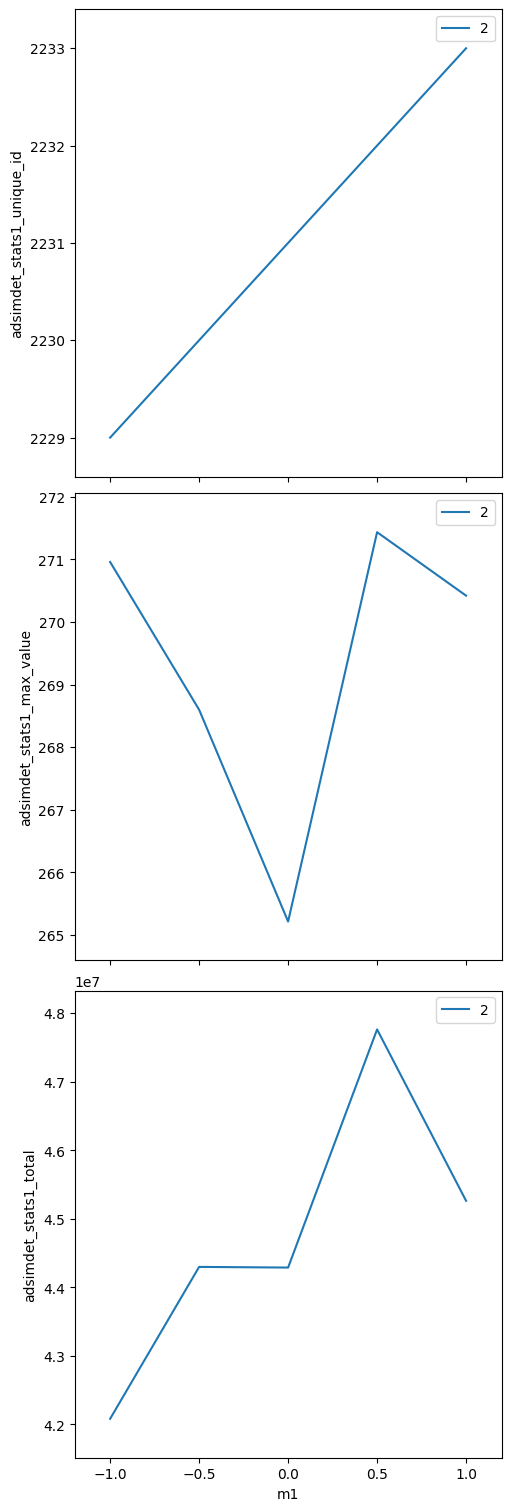

In [7]:
uids = RE(bp.scan([adsimdet], m1, -1, 1, 5))
dataset = cat.v2[uids[-1]].primary.read()
dataset[["m1", "adsimdet_stats1_total", "adsimdet_stats1_max_value"]]

## `bp.scan` — 1-D scan with two motors together

Both motors step simultaneously; same number of points.



Transient Scan ID: 3     Time: 2026-03-27 11:41:38
Persistent Unique Scan ID: '243b6fb1-19eb-4231-8924-94b49522e90b'


New stream: 'primary'
+-----------+------------+------------+------------+---------------------------+---------------------------+-----------------------+
|   seq_num |       time |         m1 |         m2 | adsimdet_stats1_unique_id | adsimdet_stats1_max_value | adsimdet_stats1_total |
+-----------+------------+------------+------------+---------------------------+---------------------------+-----------------------+
|         1 | 11:41:40.8 |    -1.0000 |     0.0000 |                      2234 |                       266 |              42781027 |


|         2 | 11:41:42.0 |    -0.5000 |     0.5000 |                      2235 |                       269 |              42528148 |


|         3 | 11:41:43.2 |    -0.0000 |     1.0000 |                      2236 |                       269 |              45646485 |


|         4 | 11:41:44.4 |     0.5000 |     1.5000 |                      2237 |                       266 |              42336109 |


|         5 | 11:41:45.5 |     1.0000 |     2.0000 |                      2238 |                       267 |              43649053 |


+-----------+------------+------------+------------+---------------------------+---------------------------+-----------------------+
generator scan ['243b6fb1'] (scan num: 3)


<xarray.Dataset> Size: 160B
Dimensions:                (time: 5)
Coordinates:
  * time                   (time) float64 40B 1.775e+09 1.775e+09 ... 1.775e+09
Data variables:
    m1                     (time) float64 40B -1.0 -0.5 -2.485e-06 0.5 1.0
    m2                     (time) float64 40B 0.0 0.5 1.0 1.5 2.0
    adsimdet_stats1_total  (time) float64 40B 4.278e+07 4.253e+07 ... 4.365e+07

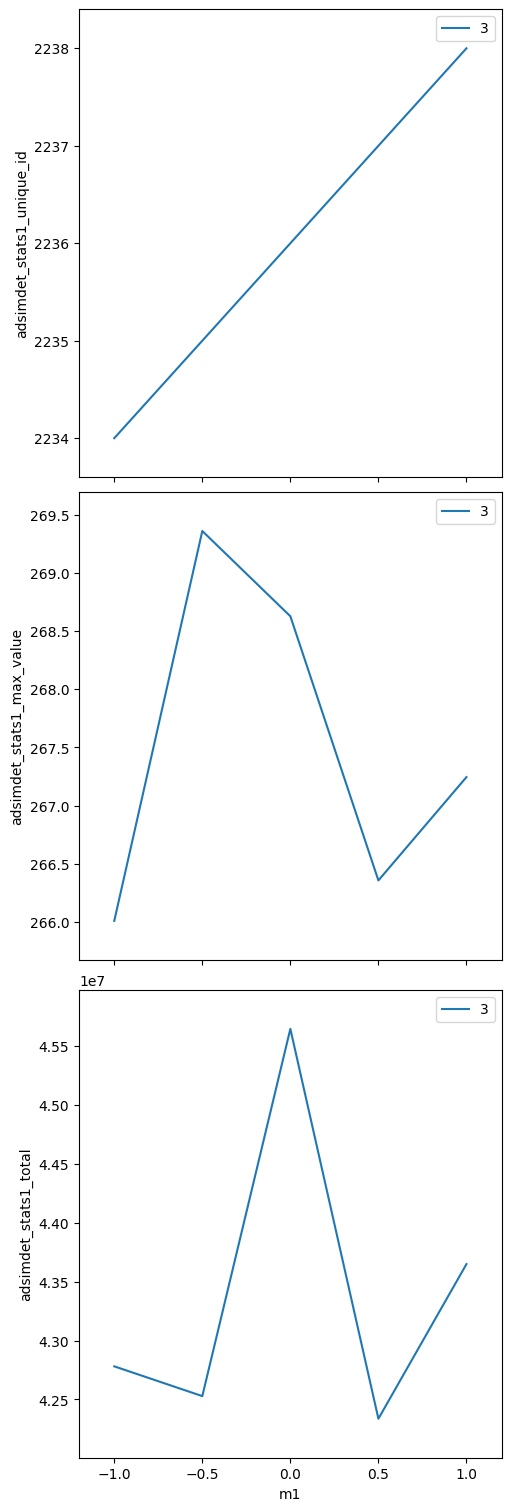

In [8]:
uids = RE(
    bp.scan(
        [adsimdet],
        m1, -1, 1,
        m2,  0, 2,
        5,
    )
)
dataset = cat.v2[uids[-1]].primary.read()
dataset[["m1", "m2", "adsimdet_stats1_total"]]

## `bp.grid_scan` — 2-D mesh scan

`m1` steps along the outer axis; `m2` steps along the inner axis (snake pattern).



Transient Scan ID: 4     Time: 2026-03-27 11:41:46
Persistent Unique Scan ID: '7ab93f40-d71f-4a12-926e-97b7d3cfc679'


New stream: 'primary'
+-----------+------------+------------+------------+---------------------------+---------------------------+-----------------------+
|   seq_num |       time |         m1 |         m2 | adsimdet_stats1_unique_id | adsimdet_stats1_max_value | adsimdet_stats1_total |
+-----------+------------+------------+------------+---------------------------+---------------------------+-----------------------+
|         1 | 11:41:49.5 |    -1.0000 |    -0.5000 |                      2239 |                       269 |              42740980 |


|         2 | 11:41:50.9 |    -1.0000 |    -0.1667 |                      2240 |                       270 |              44867476 |


|         3 | 11:41:52.2 |    -1.0000 |     0.1667 |                      2241 |                       266 |              47083689 |


|         4 | 11:41:53.6 |    -1.0000 |     0.5000 |                      2242 |                       266 |              46792656 |


...

|        10 | 11:42:03.1 |     1.0000 |    -0.1667 |                      2248 |                       265 |              51660166 |


|        11 | 11:42:04.4 |     1.0000 |     0.1667 |                      2249 |                       268 |              52460988 |


|        12 | 11:42:05.7 |     1.0000 |     0.5000 |                      2250 |                       269 |              50229264 |


+-----------+------------+------------+------------+---------------------------+---------------------------+-----------------------+
generator grid_scan ['7ab93f40'] (scan num: 4)





<xarray.Dataset> Size: 480B
Dimensions:                    (time: 12)
Coordinates:
  * time                       (time) float64 96B 1.775e+09 ... 1.775e+09
Data variables:
    m1                         (time) float64 96B -1.0 -1.0 -1.0 ... 1.0 1.0 1.0
    m2                         (time) float64 96B -0.5 -0.1667 ... 0.1667 0.5
    adsimdet_stats1_total      (time) float64 96B 4.274e+07 ... 5.023e+07
    adsimdet_stats1_max_value  (time) float64 96B 269.2 270.4 ... 268.4 269.4

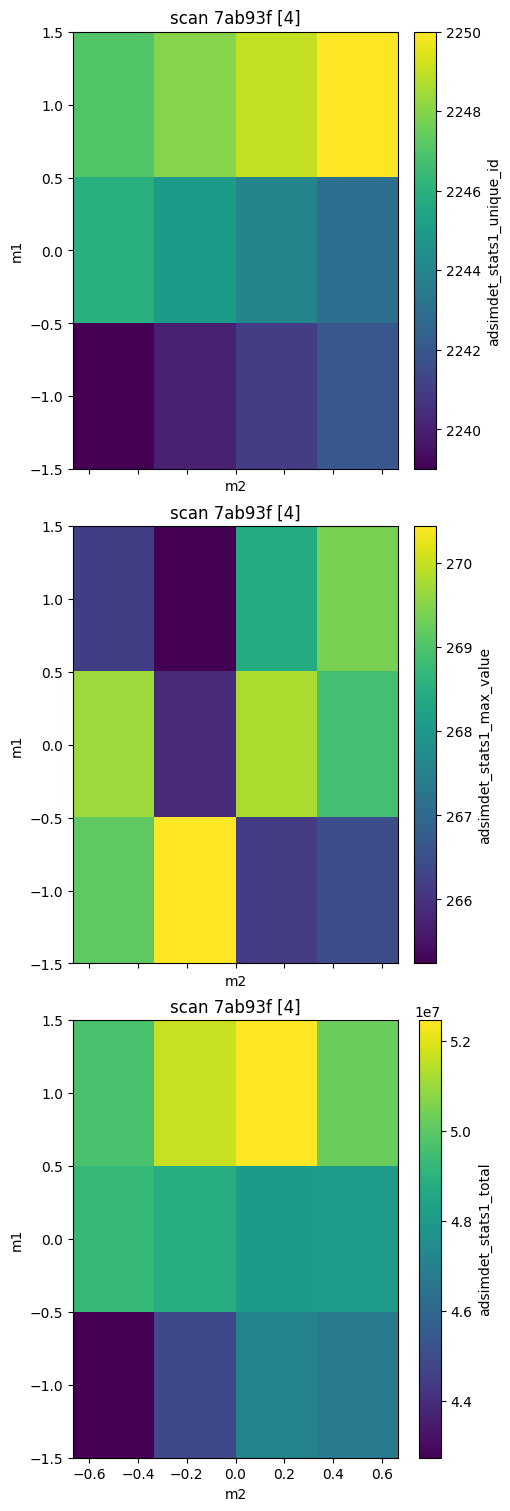

In [9]:
uids = RE(
    bp.grid_scan(
        [adsimdet],
        m1, -1, 1, 3,
        m2, -0.5, 0.5, 4,
        snake_axes=True,
    )
)
dataset = cat.v2[uids[-1]].primary.read()
dataset[["m1", "m2", "adsimdet_stats1_total", "adsimdet_stats1_max_value"]]